In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb

In [3]:
df = pd.read_csv('..\\data\\segment2.csv')
df.head()

,lat,long,age,q_ihfc,q_ps,q_stein,ps_z,stein_z
0,48.7500,-127.75,2.906279,200.0,277.518538,299.158617,3096.673436,3222.245155
1,47.8983,-127.20,4.359262,161.0,226.597009,244.266377,3230.759601,3362.077870
2,47.8983,-127.65,3.190760,304.0,264.858297,285.511167,3125.194460,3251.988508
3,48.6833,-126.87,5.543758,60.8,200.936360,216.604786,3324.081515,3459.399294
4,48.6850,-126.87,5.543758,63.7,200.936360,216.604786,3324.081515,3459.399294


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [4]:
x = df.drop(columns=['q_ihfc','q_ps','q_stein', 'stein_z'])
y = df['q_ps']

In [5]:
x.head()

,lat,long,age,ps_z
0,48.7500,-127.75,2.906279,3096.673436
1,47.8983,-127.20,4.359262,3230.759601
2,47.8983,-127.65,3.190760,3125.194460
3,48.6833,-126.87,5.543758,3324.081515
4,48.6850,-126.87,5.543758,3324.081515


In [6]:
x.shape

(3691, 4)

In [7]:
y.head()

0    277.518538
1    226.597009
2    264.858297
3    200.936360
4    200.936360
Name: q_ps, dtype: float64

In [8]:
ts = 0.2

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts)

In [9]:
x_train.shape

(2952, 4)

this is the raw validation data

In [10]:
x_test.shape

(739, 4)

In [11]:
x_train.describe().round(3)

,lat,long,age,ps_z
count,2952.000,2952.000,2952.000,2952.000
mean,48.168,-128.314,1.769,2918.779
std,0.322,0.656,1.638,203.232
min,47.686,-129.502,0.009,2533.013
25%,47.884,-128.710,0.592,2769.203
50%,48.259,-128.640,0.912,2834.305
75%,48.455,-127.786,3.251,3131.081
max,48.997,-126.223,6.688,3405.155


In [12]:
x_test.describe().round(3)

,lat,long,age,ps_z
count,739.000,739.000,739.000,739.000
mean,48.182,-128.321,1.768,2916.987
std,0.326,0.665,1.654,206.901
min,47.689,-129.505,0.009,2533.013
25%,47.880,-128.710,0.592,2769.203
50%,48.350,-128.647,0.867,2825.818
75%,48.455,-127.784,3.191,3125.194
max,48.908,-126.223,6.688,3405.155


In [13]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

In [14]:
lr = 0.1

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'verbose':-1
}

In [15]:
nbr = 100
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

In [16]:
y_pred = model.predict(x_test)

In [17]:
y_pred, y_pred.shape

(array([ 615.09511298,  437.80032754,  495.38643997, 2757.49588386,
         508.43649046,  262.39061681,  262.39061681,  531.08443241,
         531.15296553,  437.76534488,  437.8264773 ,  495.31928519,
         531.15296553,  265.05553367,  432.65555506, 5017.57995183,
         184.10702251,  581.06275097,  580.78549399,  495.31928519,
         531.15296553,  200.96249013,  200.96249013,  262.39061681,
         200.96249013,  220.0624568 ,  184.78990994,  508.24840767,
         429.0212706 ,  437.80032754,  188.80032442,  649.96509423,
         508.04673468,  262.39061681,  193.67490829,  615.09740507,
         253.11720447,  615.09511298,  464.95790794,  615.13546028,
         649.40073397,  262.39061681,  432.65555506,  530.89858449,
         650.09030294,  264.80738949,  581.45754739,  531.15296553,
         318.25122786,  233.33778454,  262.39061681,  437.76583538,
         641.29022538,  262.39061681,  437.76583538,  649.66077201,
         283.60067879,  262.39061681,  615.09511

In [18]:
residuals = y_test - y_pred

negative mean: overpredicting

In [19]:
residuals.head(), residuals.describe()

(3256    0.009282
 1190   -0.020986
 1153   -0.066131
 3172   -3.561349
 2960   -0.214214
 Name: q_ps, dtype: float64,
 count    739.000000
 mean      -0.244931
 std        4.885890
 min     -111.390217
 25%       -0.035789
 50%        0.001024
 75%        0.015771
 max       18.327477
 Name: q_ps, dtype: float64)

In [20]:
dfr = pd.DataFrame({
    'long': x_test['long'].values,
    'lat': x_test['lat'].values,
    'ps_q_test_data': y_test,
    'ps_q_predicted': y_pred,
    'residual': residuals
})

saving both the csv file and a text file of specified parameters

In [21]:
pd.DataFrame(dfr).to_csv('..\\created_data\\seg2_ps_q_residuals.csv', index=False)

with open('..\\created_data\\seg2_ps_q_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\n')
    f.write(f'gives mean of: {residuals.mean()}')

In [22]:
import matplotlib.pyplot as plt

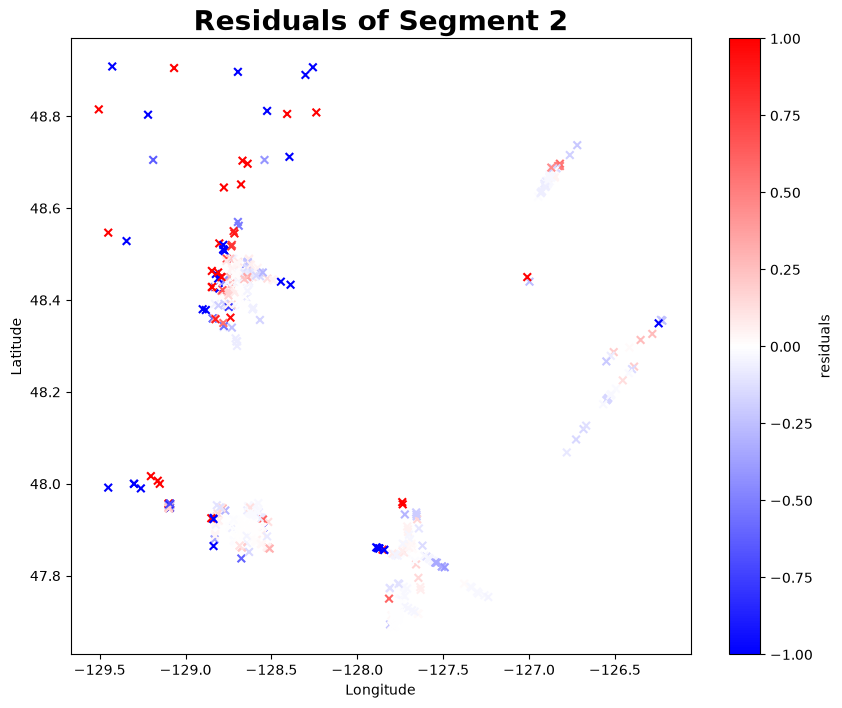

In [23]:
plt.figure(figsize=(10, 8))
plt.scatter(x_test['long'], x_test['lat'], c=residuals, cmap='bwr',
            marker='x', s=30, vmin=-1, vmax=1)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Heat Flow Residals (Seg 2)', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\res_ps_q_seg2.png', dpi=400)
plt.show()